In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense
from src.visualization import generate_histogram_from_array

In [2]:
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=1)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)

variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
           variable_names.DEAL_ORDERS: orders,
           variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
           variable_names.DEAL_SELLING_PRICE: selling_price,
           variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
# advertising_efficiency_model = AdvertisingEfficiencyModel()
# free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()

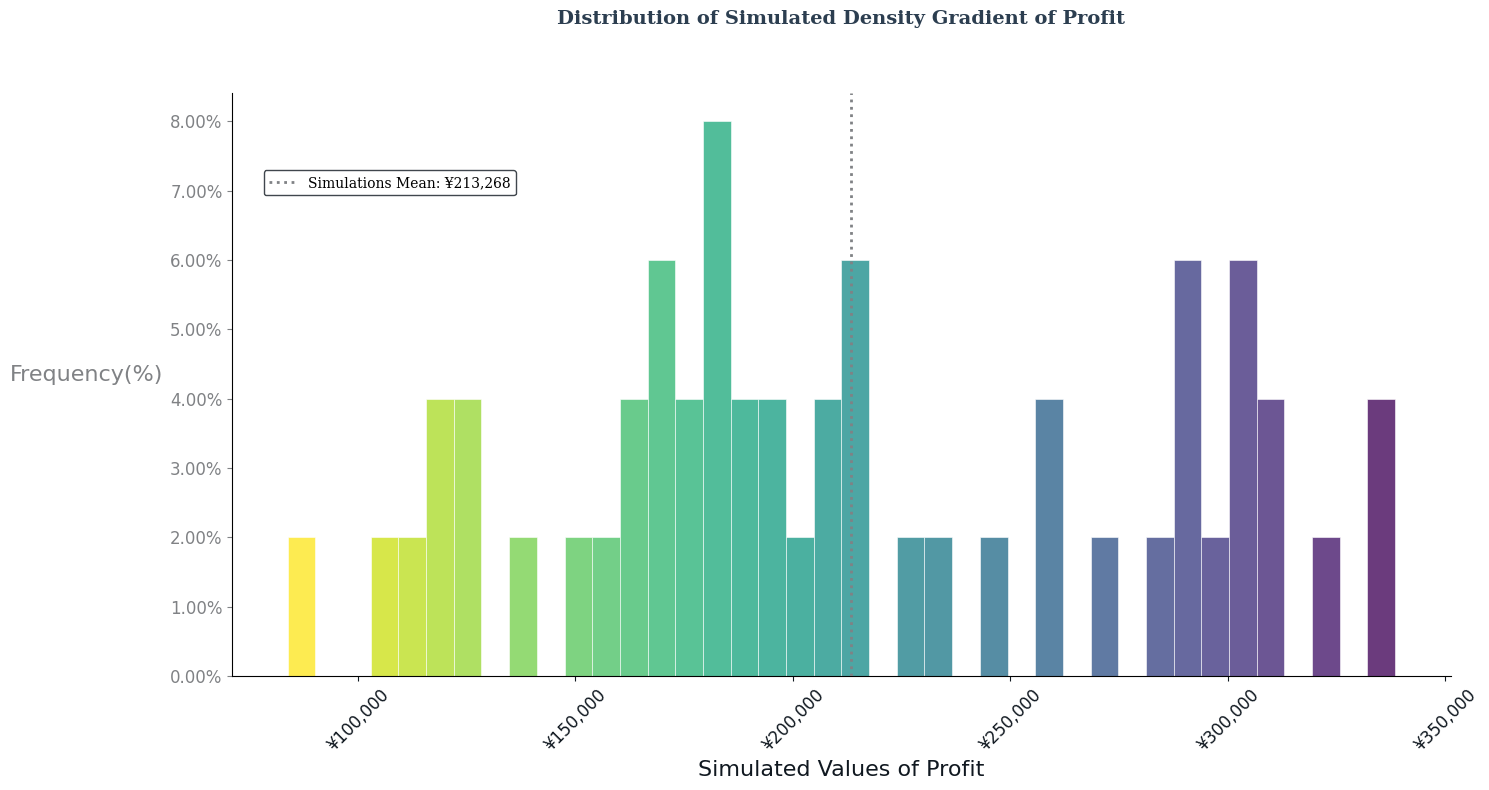

In [3]:
simulations = run_monte_carlo(variables, [variable_names.DEAL_PURCHASING_PRICE,
                                          variable_names.DEAL_SELLING_PRICE],
                              [cogs_model, revenue_model, cost_model, expense_model, depreciation_model,
                               capital_expenditure_model, profit_model],
                              tracked_outputs=[variable_names.PROFIT],
                              iterations=50)
generate_histogram_from_array(simulations, variable_names.PROFIT)
plt.show()

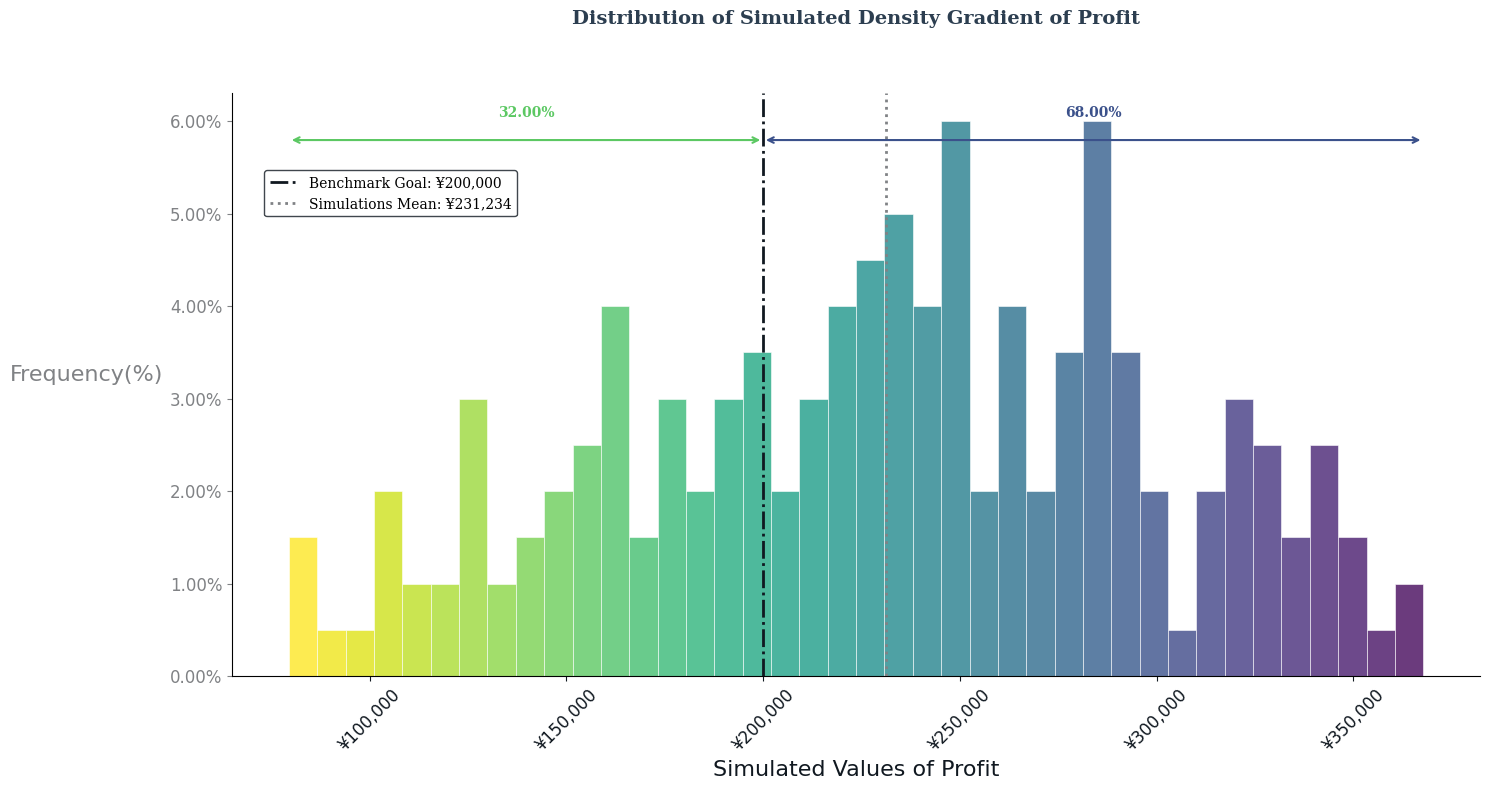

In [4]:
simulations = run_monte_carlo(variables, [variable_names.DEAL_PURCHASING_PRICE,
                                          variable_names.DEAL_SELLING_PRICE],
                              [cogs_model, revenue_model, cost_model, expense_model, depreciation_model,
                               capital_expenditure_model, profit_model],
                              tracked_outputs=[variable_names.PROFIT],
                              iterations=200)

benchmark_goal = 200000
generate_histogram_from_array(simulations, variable_names.PROFIT, benchmark_goal)
plt.show()